In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [ ]:
df = pd.read_csv('/content/Iris.csv')
print(df.head())
print("Shape:", df.shape)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Shape: (150, 6)


In [ ]:
print(df['Species'].value_counts())
print(df.isnull().sum())
print(df.describe())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [ ]:
df.drop(columns=['Id'], inplace=True)
print(df.columns)

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [ ]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

le = LabelEncoder()
y = le.fit_transform(y)

print("X shape:", X.shape)
print("Classes:", le.classes_)

X shape: (150, 4)
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (120, 4)
Test: (30, 4)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred) * 100, "%")

KNN Accuracy: 93.33333333333333 %


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred) * 100, "%")

Decision Tree Accuracy: 90.0 %


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred) * 100, "%")

Random Forest Accuracy: 90.0 %


In [ ]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred) * 100, "%")

SVM Accuracy: 96.66666666666667 %


In [ ]:
print("---- Model Comparison ----")
print("KNN           :", round(accuracy_score(y_test, knn_pred) * 100, 2), "%")
print("Decision Tree :", round(accuracy_score(y_test, dt_pred)  * 100, 2), "%")
print("Random Forest :", round(accuracy_score(y_test, rf_pred)  * 100, 2), "%")
print("SVM           :", round(accuracy_score(y_test, svm_pred) * 100, 2), "%")

---- Model Comparison ----
KNN           : 93.33 %
Decision Tree : 90.0 %
Random Forest : 90.0 %
SVM           : 96.67 %


In [ ]:
print(classification_report(y_test, svm_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



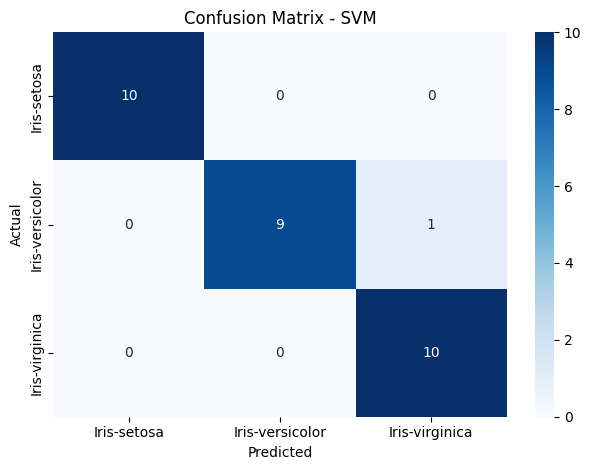

In [ ]:
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

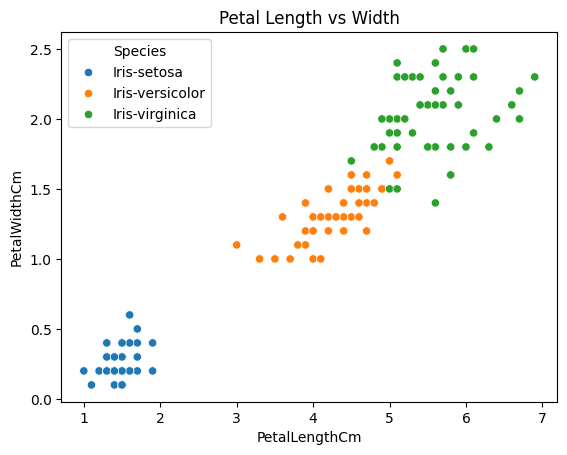

In [ ]:
colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'blue', 'Iris-virginica': 'green'}
for species, color in colors.items():
    mask = df['Species_name'] if 'Species_name' in df.columns else None

# Simple version:
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species')
plt.title("Petal Length vs Width")
plt.show()

In [ ]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
new_flower_scaled = scaler.transform(new_flower)
result = svm.predict(new_flower_scaled)
print("Predicted Species:", le.inverse_transform(result)[0])


Predicted Species: Iris-virginica


In [ ]:
new_flower = [[6.0, 2.9, 4.5, 1.5]]
new_flower_scaled = scaler.transform(new_flower)
result = svm.predict(new_flower_scaled)
print("Predicted Species:", le.inverse_transform(result)[0])


Predicted Species: Iris-setosa


In [ ]:
new_flower = [[6.7, 3.1, 5.6, 2.4]]
new_flower_scaled = scaler.transform(new_flower)
result = svm.predict(new_flower_scaled)
print("Predicted Species:", le.inverse_transform(result)[0])


Predicted Species: Iris-setosa
